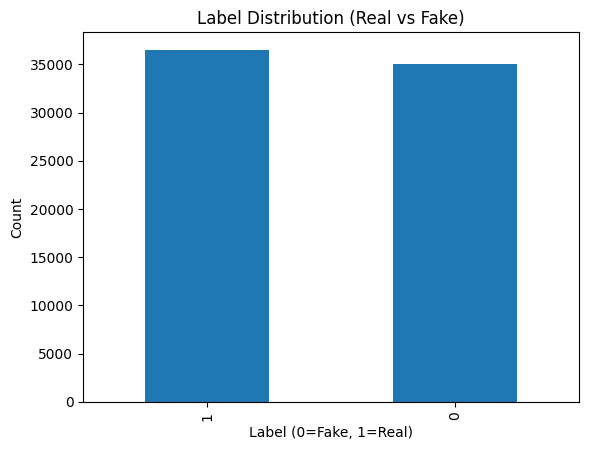

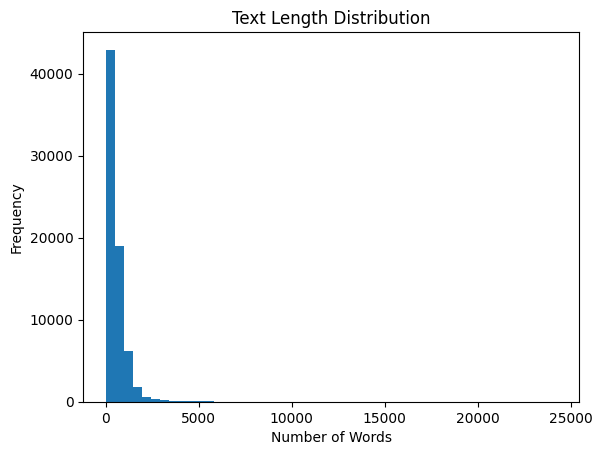

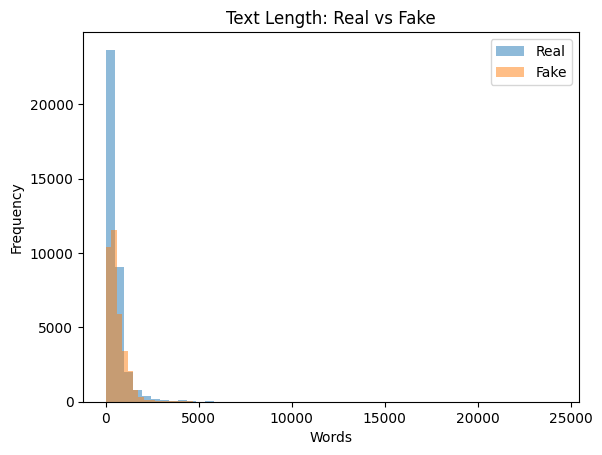

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\bhati\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


KeyboardInterrupt: 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# LOAD DATA
df = pd.read_csv("WELFake_Dataset.csv")
df = df.dropna(subset=['title', 'text', 'label'])
df['text'] = df['title'] + " " + df['text']

# =========================
# 1. LABEL DISTRIBUTION
# =========================
plt.figure()
df['label'].value_counts().plot(kind='bar')
plt.title("Label Distribution (Real vs Fake)")
plt.xlabel("Label (0=Fake, 1=Real)")
plt.ylabel("Count")
plt.show()

# =========================
# 2. TEXT LENGTH DISTRIBUTION
# =========================
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure()
plt.hist(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# =========================
# 3. REAL VS FAKE LENGTH COMPARISON
# =========================
real = df[df['label'] == 1]['text_length']
fake = df[df['label'] == 0]['text_length']

plt.figure()
plt.hist(real, bins=50, alpha=0.5, label='Real')
plt.hist(fake, bins=50, alpha=0.5, label='Fake')
plt.legend()
plt.title("Text Length: Real vs Fake")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

# =========================
# 4. SENTIMENT DISTRIBUTION
# =========================
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

df['sentiment'] = df['text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

plt.figure()
plt.hist(df['sentiment'], bins=50)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()